In [1]:
import torch
import matplotlib.pyplot as plt

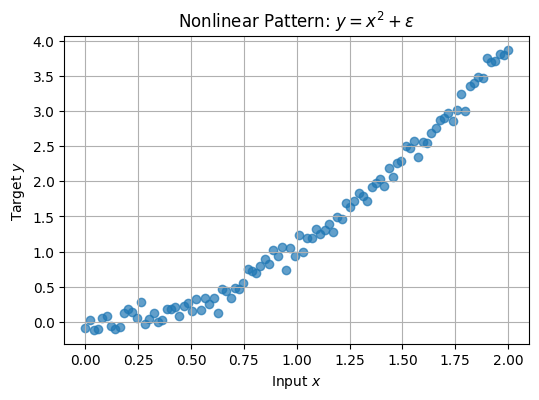

In [2]:
x = torch.linspace(0, 2, 100).unsqueeze(1)
y = x**2 + 0.1 * torch.randn_like(x)

plt.figure(figsize=(6, 4))
plt.scatter(x.numpy(), y.numpy(), alpha=0.7)
plt.title('Nonlinear Pattern: $y = x^2 + \\epsilon$')  # Or: 'y = x² + noise'
plt.xlabel('Input $x$')
plt.ylabel('Target $y$')
plt.grid(True)
plt.show()

In [3]:
def mse_loss(preds, targets):
    return ((preds - targets)**2).mean()

In [6]:
torch.manual_seed(42)
input_dim = 1
hidden_dim = 5
output_dim = 1

W1_lin = torch.randn(input_dim, hidden_dim, requires_grad=True)
b1_lin = torch.randn(hidden_dim, requires_grad=True)
W2_lin = torch.randn(hidden_dim, output_dim, requires_grad=True)
b2_lin = torch.randn(output_dim, requires_grad=True)

def predict_linear(X):
    hidden = X @ W1_lin + b1_lin
    output = hidden @ W2_lin + b2_lin
    return output

In [7]:
W1_relu = torch.randn(input_dim, hidden_dim, requires_grad=True)
b1_relu = torch.randn(hidden_dim, requires_grad=True)
W2_relu = torch.randn(hidden_dim, output_dim, requires_grad=True)
b2_relu = torch.randn(output_dim, requires_grad=True)

def my_relu(x):
    return torch.clamp(x, min=0)

def predict_relu(X):
    hidden = my_relu(X @ W1_relu + b1_relu)
    output = hidden @ W2_relu + b2_relu
    return output

In [8]:
lr = 0.01
epochs = 3000

losses_linear = []
losses_relu = []

for epoch in range(epochs):
    
    # ===== Linear → Linear =====
    preds_lin = predict_linear(x)
    loss_lin = mse_loss(preds_lin, y)
    loss_lin.backward()

    with torch.no_grad():
        W1_lin -= lr * W1_lin.grad
        b1_lin -= lr * b1_lin.grad
        W2_lin -= lr * W2_lin.grad
        b2_lin -= lr * b2_lin.grad
        
        # Zero gradients
        W1_lin.grad.zero_()
        b1_lin.grad.zero_()
        W2_lin.grad.zero_()
        b2_lin.grad.zero_()

    losses_linear.append(loss_lin.item())

    # ===== Linear → ReLU → Linear =====
    preds_relu = predict_relu(x)
    loss_relu = mse_loss(preds_relu, y)
    loss_relu.backward()

    with torch.no_grad():
        W1_relu -= lr * W1_relu.grad
        b1_relu -= lr * b1_relu.grad
        W2_relu -= lr * W2_relu.grad
        b2_relu -= lr * b2_relu.grad

        W1_relu.grad.zero_()
        b1_relu.grad.zero_()
        W2_relu.grad.zero_()
        b2_relu.grad.zero_()

    losses_relu.append(loss_relu.item())




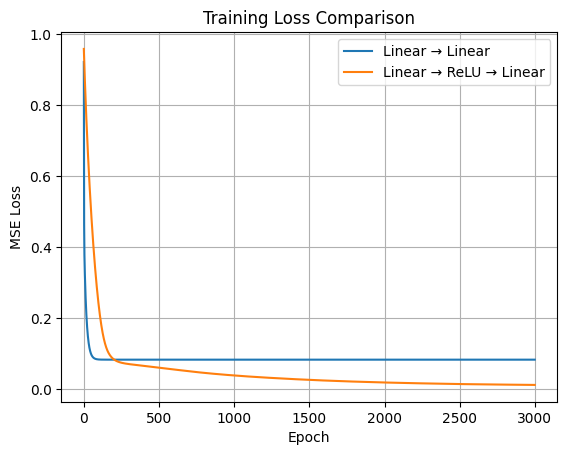

In [9]:
plt.plot(losses_linear, label='Linear → Linear')
plt.plot(losses_relu, label='Linear → ReLU → Linear')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
y_pred_lin = predict_linear(x).detach()
y_pred_relu = predict_relu(x).detach()

sorted_idx = torch.argsort(x.squeeze())

x_sorted = x.squeeze()[sorted_idx]
y_sorted_true = y.squeeze()[sorted_idx]
y_sorted_lin = y_pred_lin.squeeze()[sorted_idx]
y_sorted_relu = y_pred_relu.squeeze()[sorted_idx]

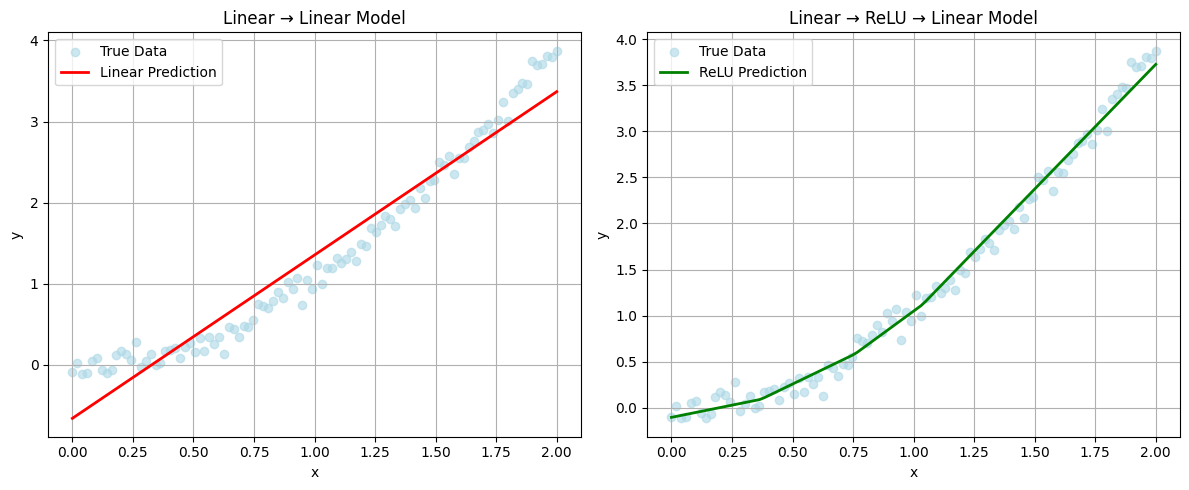

In [11]:
plt.figure(figsize=(12, 5))

# Subplot 1 — Linear ➔ Linear
plt.subplot(1, 2, 1)
plt.scatter(x_sorted.numpy(), y_sorted_true.numpy(), color='lightblue', label='True Data', alpha=0.6)
plt.plot(x_sorted.numpy(), y_sorted_lin.numpy(), color='red', label='Linear Prediction', linewidth=2)
plt.title('Linear → Linear Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Subplot 2 — Linear ➔ ReLU ➔ Linear
plt.subplot(1, 2, 2)
plt.scatter(x_sorted.numpy(), y_sorted_true.numpy(), color='lightblue', label='True Data', alpha=0.6)
plt.plot(x_sorted.numpy(), y_sorted_relu.numpy(), color='green', label='ReLU Prediction', linewidth=2)
plt.title('Linear → ReLU → Linear Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [13]:
print("Linear to Linear")
print(W1_lin[0], "X + ", b1_lin[0])
print(W2_lin[0], "X + ", b2_lin[0])

print()
print("With Actuvation function")
print(W1_relu[0], "X + ", b1_relu[0])
print(W2_relu[0], "X + ", b2_relu[0])

Linear to Linear
tensor([ 0.3889,  0.1846,  0.3431,  0.0717, -1.2207],
       grad_fn=<SelectBackward0>) X +  tensor(-0.2524, grad_fn=<SelectBackward0>)
tensor([0.5939], grad_fn=<SelectBackward0>) X +  tensor(0.8387, grad_fn=<SelectBackward0>)

With Actuvation function
tensor([ 1.4843,  0.8918, -0.5770, -0.8001,  1.3667],
       grad_fn=<SelectBackward0>) X +  tensor(0.2578, grad_fn=<SelectBackward0>)
tensor([0.5683], grad_fn=<SelectBackward0>) X +  tensor(-0.0481, grad_fn=<SelectBackward0>)
